https://archive.ics.uci.edu/ml/datasets/student+performance

In [2]:
import numpy as np
import pandas as pd
from copy import deepcopy
from sklearn.utils import shuffle
from scipy.stats import ranksums
from catboost import CatBoostRegressor, Pool
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor,BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import warnings
from math import log2
from time import time
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.model_selection import KFold
from sklearn.base import clone
import warnings
from typing import Optional, Dict, Any, List, Tuple, Union
warnings.filterwarnings('ignore')
import skfuzzy as fuzz

def KFoldCV(model, data, n_fold=10, random_state=42, shuffle=True):
    X, y = data[:, :-1], data[:, -1]
    kf = KFold(n_splits=n_fold, shuffle=shuffle, random_state=random_state)
    
    results = np.zeros((n_fold, 4))
    
    for i, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # clone to avoid leakage
        model_i = clone(model)
        model_i.fit(X_train, y_train)
        y_pred = model_i.predict(X_test)
        
        mae = np.mean(np.abs(y_test - y_pred))
        stdErr = np.std(y_test - y_pred)
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        MAC = (np.dot(y_test, y_pred) ** 2) / (np.dot(y_test, y_test) * np.dot(y_pred, y_pred))
        
        results[i, :] = [mae, stdErr, rmse, MAC]
    
    return results

C:\Users\Zongwen\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
data = pd.read_csv('../student-mat.csv', sep=';')
cats = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences']
oe = OrdinalEncoder()
for c in cats:
    oe.fit(data[c].values.reshape(-1,1))
    data[c] = np.asarray(oe.transform(data[c].values.reshape(-1,1)),dtype=int)
X = data.drop(columns=['G3'])
data = data.values
data = data[:,:-2]
data = shuffle(data)

In [8]:
feature_names = np.array(['School', 'Sex', 'Age', 'Address', 'Famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'Reason', 'Guardian', 'Traveltime', 'Studytime', 'Failures', 'Schoolsup', 'Famsup', 'Paid', 'Activities', 'Nursery', 'Higher', 'Internet', 'Romantic', 'Famrel', 'Freetime', 'Goout', 'Dalc', 'Walc', 'Health', 'Absences','G1','G2'])

X.keys()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')

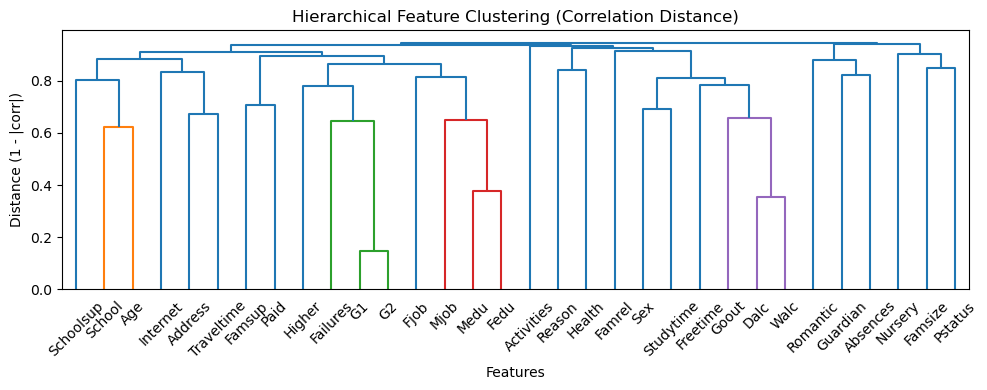

In [9]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram
# X = data[:,:-1]
n_features = X.shape[1]

corr = np.corrcoef(X, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0)

dist_mat = 1.0 - np.abs(corr)
condensed = squareform(dist_mat, checks=False)

Z = linkage(condensed, method='average')
plt.figure(figsize=(10, 4))
# feature_names = [f"f{i+1}" for i in range(n_features)]
dendrogram(
    Z,
    labels=feature_names, #data.keys()[:-1],
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=None
)
plt.title("Hierarchical Feature Clustering (Correlation Distance)")
plt.xlabel("Features")
plt.ylabel("Distance (1 - |corr|)")
plt.tight_layout()
plt.savefig('HFC.eps', format='eps',bbox_inches  ='tight')
plt.show()

In [3]:
t1 = time()
Cs = [10, 100, 1000]
gammas = [0.001, 0.01, 0.1]
# Cs = [100]
# gammas = [0.001]
epochs=1
svms = np.zeros((epochs,4))
for i in range(len(Cs)):
    for j in range(len(gammas)):
        lc = len(Cs)
        lg = len(gammas)
        for epoch in range(epochs):
            data = shuffle(data)
            model = SVR(kernel = 'rbf', C = Cs[i], gamma = gammas[j])
            result = KFoldCV(model, data)
            svms[epoch,:] = np.mean(result, axis=0)
        print(np.mean(svms, axis=0))
print(time()-t1)

[2.55671576 3.06374357 3.11830798 0.92737655]
[2.64959486 3.16739086 3.24452559 0.9209164 ]
[2.66200411 3.17829575 3.22665419 0.92068893]
[2.42908424 2.98937874 3.01344297 0.92960182]
[2.98403004 3.68662544 3.71066803 0.89537889]
[2.61487461 3.16095565 3.20157776 0.92227656]
[2.64067443 3.27360864 3.28057677 0.91696281]
[3.35778465 4.14514355 4.17660855 0.87215836]
[2.61556562 3.17510437 3.19078061 0.92166892]
1.454164743423462


In [14]:
t1 = time()
Cs = [100]
gammas = [0.001]
epochs=20
svms = np.zeros((epochs,4))
for i in range(len(Cs)):
    for j in range(len(gammas)):
        lc = len(Cs)
        lg = len(gammas)
        for epoch in range(epochs):
            data = shuffle(data)
            model = SVR(kernel = 'rbf', C = Cs[i], gamma = gammas[j])
            result = KFoldCV(model, data)
            svms[epoch,:] = np.mean(result, axis=0)
        print(np.mean(svms, axis=0))
print(time()-t1)

[2.48153175 3.04347828 3.08387355 0.92783468]
2.6544721126556396


In [34]:
svms = np.array([[2.45543714, 3.02708823, 3.04916415, 0.92863847],
       [2.47657391, 3.03574408, 3.07076792, 0.92868277],
       [2.48222729, 3.04575288, 3.07930042, 0.92789961],
       [2.47924187, 3.02623248, 3.06809301, 0.92843007],
       [2.51566938, 3.05771304, 3.10046704, 0.92724768],
       [2.47107355, 3.01445104, 3.07292706, 0.9294296 ],
       [2.44877771, 2.99960348, 3.05089703, 0.92940864],
       [2.52307246, 3.10364705, 3.13452995, 0.92454605],
       [2.49443504, 3.04014632, 3.09230639, 0.92799247],
       [2.46744032, 3.04613729, 3.0751178 , 0.92776302],
       [2.45829663, 3.05079749, 3.07486681, 0.92777018],
       [2.49853218, 3.06674072, 3.09509939, 0.92686054],
       [2.44589222, 3.01081201, 3.06334713, 0.9294855 ],
       [2.46528494, 3.05317911, 3.07289177, 0.92724911],
       [2.54895493, 3.08928661, 3.14248172, 0.9258484 ],
       [2.49214362, 3.04486609, 3.0966844 , 0.92787847],
       [2.47407146, 3.02109143, 3.07042782, 0.92917036],
       [2.51355998, 3.06673532, 3.13428657, 0.92613541],
       [2.45383575, 3.03650431, 3.05709701, 0.92799504],
       [2.46611462, 3.03303668, 3.07671768, 0.92826215]])

In [4]:
t1 = time()
epochs=20
n_estimators  = [100, 300, 500]
max_depth = [3, 4, 5]
# n_estimators  = [300]
# max_depth = [5]
rfs = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            model = RandomForestRegressor(n_estimators=i, max_depth=j)
            result = KFoldCV(model, data)
            rfs[epoch,:] = np.mean(result, axis=0)
        print(np.mean(rfs, axis=0))
print(time()-t1)

[2.51438891 2.97275581 3.01724312 0.93132233]
[2.49852008 2.9640308  3.00344032 0.93183204]
[2.48723061 2.95965943 3.00087466 0.93192018]
[2.51340194 2.9687514  3.01295566 0.9314018 ]
[2.49821308 2.95305506 3.00213226 0.93213507]
[2.4785993  2.94643131 2.98768593 0.9325656 ]
[2.51536484 2.97843959 3.01552535 0.93108878]
[2.49376518 2.95772319 2.99924507 0.93216833]
[2.48793638 2.95021325 2.99294228 0.93234648]
756.1803877353668


In [16]:
t1 = time()
epochs=20
n_estimators  = [300]
max_depth = [5]
rfs = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            model = RandomForestRegressor(n_estimators=i, max_depth=j)
            result = KFoldCV(model, data)
            rfs[epoch,:] = np.mean(result, axis=0)
        print(np.mean(rfs, axis=0))
print(time()-t1)

[2.47967097 2.95143702 2.98818395 0.93224552]
108.16269421577454


In [35]:
rfs = np.array([[2.47767549, 2.96374822, 2.98961354, 0.93183905],
       [2.47309449, 2.94557609, 2.97254337, 0.93296723],
       [2.48791433, 2.98553124, 3.00187424, 0.93059041],
       [2.47313644, 2.94630993, 2.97948484, 0.93264299],
       [2.46713923, 2.92551047, 2.9500946 , 0.93326744],
       [2.46929153, 2.92610045, 2.95345089, 0.93319596],
       [2.49615083, 2.94026646, 2.99408283, 0.93211091],
       [2.48799431, 2.97700787, 3.01399441, 0.93089464],
       [2.49768679, 2.92887354, 3.00079183, 0.93264298],
       [2.49054996, 2.95805355, 3.00166879, 0.93216265],
       [2.4931208 , 2.97604275, 3.00326169, 0.93143215],
       [2.45090446, 2.9441758 , 2.97851202, 0.93301554],
       [2.44426207, 2.92218696, 2.95565171, 0.93362523],
       [2.48135202, 2.98447845, 3.0007442 , 0.93078083],
       [2.46993803, 2.91684736, 2.96022257, 0.93394707],
       [2.46432632, 2.93039151, 2.98468341, 0.93288956],
       [2.47273143, 2.93727867, 2.98108155, 0.93290454],
       [2.49933222, 2.99573774, 3.00912688, 0.93041121],
       [2.48508394, 2.9399295 , 3.00722526, 0.93281592],
       [2.51173475, 2.98469379, 3.02557032, 0.93077402]])

In [5]:
t1 = time()
n_estimators= [100,300,500]
max_depth = [3,4, 5]
# n_estimators  = [100]
# max_depth = [3]
cats = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            model = CatBoostRegressor(n_estimators=i, max_depth=j,verbose=False)
            result = KFoldCV(model, data)
            cats[epoch,:] = np.mean(result, axis=0)
        print(np.mean(cats, axis=0))

[2.45659734 2.96214078 3.00586203 0.93186205]
[2.50813981 3.03794604 3.07826261 0.92831879]
[2.49965295 3.02351175 3.07675169 0.9290056 ]
[2.47531986 2.98187751 3.02237369 0.93099581]
[2.49184177 3.01131446 3.0552385  0.9295665 ]
[2.49471641 3.01293418 3.05444798 0.92959904]
[2.47734449 2.98214769 3.03034699 0.93083682]
[2.49433049 3.01694855 3.05841463 0.92924027]
[2.48924188 3.0163759  3.05729554 0.92925938]


In [18]:
t1 = time()
n_estimators  = [100]
max_depth = [3]
cats = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            model = CatBoostRegressor(n_estimators=i, max_depth=j,verbose=False)
            result = KFoldCV(model, data)
            cats[epoch,:] = np.mean(result, axis=0)
        print(np.mean(cats, axis=0))

[2.46471565 2.98391294 3.01832317 0.9308136 ]


In [36]:
cats = np.array([[2.52051065, 3.02360437, 3.06784424, 0.9287604 ],
       [2.46505733, 2.95311434, 3.0149239 , 0.93213794],
       [2.44211512, 2.97431338, 3.00967432, 0.93113174],
       [2.44438142, 2.96872388, 2.994564  , 0.93052106],
       [2.48300838, 3.02488239, 3.05276564, 0.92915213],
       [2.46526119, 2.96984247, 3.0064447 , 0.93174528],
       [2.49734055, 3.04312966, 3.08334784, 0.92825938],
       [2.50864055, 3.00368548, 3.05490899, 0.92982502],
       [2.43610319, 2.99952845, 3.0178785 , 0.93012189],
       [2.44021347, 2.96116477, 2.99138702, 0.9320031 ],
       [2.44871923, 2.95114705, 2.98147295, 0.93209621],
       [2.46065799, 3.0016806 , 3.039447  , 0.93065548],
       [2.46814296, 3.008901  , 3.03358614, 0.93004753],
       [2.50295694, 3.02871028, 3.0682528 , 0.92888231],
       [2.39138035, 2.90742575, 2.93497427, 0.93415787],
       [2.44447736, 2.95629031, 2.98325488, 0.93153011],
       [2.49248473, 2.98684751, 3.02172773, 0.93099937],
       [2.44222993, 2.93901116, 2.97088749, 0.93266001],
       [2.4645237 , 2.97565144, 3.02848215, 0.93146329],
       [2.47610805, 3.00060455, 3.0106388 , 0.93012186]])

# EIL-CatBoost

In [3]:
from sklearn.model_selection import GridSearchCV

# 1. divide the features into selected features and the abandon features based on a given threshold
# return the index for the selected features and the abandon features
def getSelAndAbFeatures(train, threshold):
    model = RandomForestRegressor().fit(train[:,:-1], train[:,-1])
    importances = model.feature_importances_
    ind = np.argsort(importances)[::-1]
    selected = []
    abandon = []
    s = 0
    for i in ind:
        if s < threshold or len(selected) < len(ind)/4:
            selected.append(i)
        else:
            abandon.append(i)
        s = s + importances[i]
#     print("#Selected features: " + str(len(selected)))
    return selected,abandon

# grid search for hyper-parameter optimization
def gridSearch4CatBoost(data,n_estimators,max_depth):
#     cbc = CatBoostRegressor(verbose=False,task_type="GPU",devices='0:1', n_estimators=n_estimators, max_depth=max_depth)
    cbc = CatBoostRegressor(verbose=False,task_type="GPU",devices='0:1')
    return cbc.fit(data[:,:-1],data[:,-1])
#     grid = {'max_depth': [3,4,5],'n_estimators':[100,200,300]}
#     gscv = GridSearchCV (estimator = cbc, param_grid = grid, cv = 2)
#     gscv.fit(data[:,:-1],data[:,-1])
#     return gscv.best_estimator_


# iterative learning to optimize the error iteration by iteration
def iterativeLearning(train, test, error, iteration, threshold,n_estimators=100,max_depth=3):
#     ind = ind[::-1]
    selected,abandon = getSelAndAbFeatures(train, threshold)
    selectedModel, abandonModel, errorTrain, errorPredict, predictYtrain, predictY = getIteration(train, test,selected,abandon,n_estimators,max_depth)
    abFeaturesTrain = train[:,abandon]
    abFeaturesTest = test[:,abandon]
    yt = train[:,-1]
    y = test[:,-1]
    pt = predictYtrain
    p  = predictY
#     RMSE1 = np.sqrt(sum((yt-pt)**2)/len(y))
#     RMSE2 = np.sqrt(sum((y-p)**2)/len(y))
    RMSE1 = np.sqrt(sum((errorTrain)**2)/len(errorTrain))
#     RMSE2 = np.sqrt(sum((errorY)**2)/len(errorY))
#     print("RMSE: ", RMSE1)
    it = 1
    eTest = errorPredict
    while (RMSE1 > error and it < iteration):
        eTrain = yt - pt
#         eTest = errorPredict
#         print(eTrain)
        eTrain, eTest = updateAbandonModel(abFeaturesTrain, abFeaturesTest, eTrain, eTest,n_estimators,max_depth)
        p = p + eTest
        pt = pt + eTrain
        eTest = predictY - p
        RMSE1 = np.sqrt(sum((yt-pt)**2)/len(y))
#         print(it, "RMSE: ", RMSE1)
        it = it + 1
    return pt, p

# iterative learning to optimize the error iteration by iteration
def getIteration(train, test,selected,abandon,n_estimators,max_depth):
#     fit the target y using the selected features
#     print(train[:,selected].shape, train[:, -1].reshape(-1,1).shape)
    selectedModel = gridSearch4CatBoost(np.hstack((train[:,selected], train[:, -1].reshape(-1,1))),n_estimators,max_depth)
    predictYtrain = selectedModel.predict(train[:,selected])
    predictY = selectedModel.predict(test[:,selected])
    errorTrain = train[:, -1] - predictYtrain
    errorY = test[:,-1] - predictY
#     fit the error using the abandon features
    abandonModel = gridSearch4CatBoost(np.hstack((train[:,abandon], errorTrain.reshape(-1,1))),n_estimators,max_depth)
    errorPredict = abandonModel.predict(test[:,abandon])
    return selectedModel, abandonModel, errorTrain, errorPredict, predictYtrain, predictY

def updateAbandonModel(abFeaturesTrain, abFeaturesTest, errorTrain, errorY,n_estimators,max_depth):
    abandonModel = gridSearch4CatBoost(np.hstack((abFeaturesTrain, errorTrain.reshape(-1,1))),n_estimators,max_depth)
    yTrain = abandonModel.predict(abFeaturesTrain)
    yPredict = abandonModel.predict(abFeaturesTest)
#     return errorTrain - yTrain, errorY - yPredict
    return yTrain, yPredict

def KFold(data, iteration, n_fold,threshold, n_estimators,max_depth):
#     num = len(data)
    diff = int(len(data)/n_fold)
    results = np.zeros((n_fold, 4))
    for i in range(n_fold):
        begin = diff*i
        end = diff*(i+1)
        if i == n_fold-1:
            end = -1
        test = data[begin:end]
        train = deepcopy(data)
        train = np.delete(train, range(begin, end),axis=0)
        y = test[:,-1]
        yTrain, predictY = iterativeLearning(train, test, error=0.6, iteration=iteration,threshold=threshold,n_estimators=n_estimators,max_depth=max_depth)
        mae = np.mean(abs((y-predictY)))
        stdErr = np.std(((y-predictY)))
        error=sum((y-predictY)**2)
        RMSE=np.sqrt(error/len(y))
        MAC = np.dot(y,predictY)**2/(np.dot(y, y)*np.dot(predictY, predictY))
#         print(mae, stdErr, RMSE, MAC)
        results[i,:] = [mae, stdErr, RMSE, MAC]
#         print(results[i,:])
    return results


t1 = time()
n_estimators= [100,300,500]
max_depth = [3,4, 5]
n_estimators  = [500]
max_depth = [4]
epochs=20
cats = np.zeros((epochs,4))
iteration = 3
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            result =KFold(data,iteration,10,0.99,i,j)
            cats[epoch,:] = np.mean(result, axis=0)
        print(np.mean(cats, axis=0))
print(time()-t1)
# n_estimators  = [500]
# max_depth = [4]
# [2.36911615 2.84109288 2.88266414 0.93658407]
# [2.36132011 2.84623145 2.91295631 0.93459501]
# [2.33627409 2.8958016  2.9111159  0.93125944]
# [2.42147875 2.8693833  2.95631863 0.93446008]
# [2.38384695 2.82894271 2.89234315 0.9353607 ]
# [2.30111887 2.76438606 2.84700537 0.93807469]
# [2.33194323 2.82984316 2.85824454 0.93749913]
# [2.32972912 2.79825153 2.83449019 0.93666511]
# [2.36273888 2.88974299 2.91283519 0.9319746 ]
# 63.89964318275452

[2.31868742 2.8163397  2.85912312 0.93612691]


In [ ]:
eils = np.array([[2.37104376, 2.90562596, 2.93644615, 0.93196905],
       [2.30701743, 2.82179493, 2.8413184 , 0.9359952 ],
       [2.34639012, 2.85842992, 2.89233836, 0.93305806],
       [2.24565718, 2.74957643, 2.79657403, 0.939535  ],
       [2.26678091, 2.76730275, 2.79998481, 0.93890105],
       [2.33411013, 2.86575806, 2.89449486, 0.93454421],
       [2.3650012 , 2.83615598, 2.90183718, 0.9350435 ],
       [2.20165181, 2.71309785, 2.74371982, 0.94136892],
       [2.30052305, 2.78841966, 2.83880367, 0.9383055 ],
       [2.30128322, 2.84357911, 2.86369972, 0.93584392],
       [2.36114335, 2.85322972, 2.91920658, 0.93511608],
       [2.3279758 , 2.82208308, 2.87635425, 0.93512582],
       [2.31989468, 2.8018436 , 2.86023174, 0.93746928],
       [2.30892288, 2.79208712, 2.82999994, 0.93584749],
       [2.32703688, 2.81314176, 2.85846386, 0.93530622],
       [2.35108993, 2.8712668 , 2.8910778 , 0.93346493],
       [2.34992538, 2.8057412 , 2.85970026, 0.93577513],
       [2.30564062, 2.74776423, 2.80882891, 0.93940271],
       [2.33501051, 2.83319853, 2.86632045, 0.93539959],
       [2.34764965, 2.8366974 , 2.9030617 , 0.93506649]])

# DCatBoostF

In [4]:
from sklearn.model_selection import GridSearchCV


def deepCatBoostBackward(train, test,importances,ind):
    s = 0
    inds = []
    inds2 = []
    inds3 = []
    for i in ind:
        s = s + importances[i]
        inds.append(i)
#     70% importance for the first layer
        if (s > 0.9):
            model = gridSearch4CatBoost(train[:,inds], train[:,-1])
            predY = model.fit(train[:,inds], train[:,-1]).predict(train[:,inds])
            predY2 = model.predict(test[:,inds])
        else:
            inds2.append(i)
#     20% importance for the second layer
            if (s > 0.95):
                tempTrain = np.array([train[:,inds2],predY])
                tempTest = np.array([test[:,inds2],predY2])
                model = gridSearch4CatBoost(tempTrain, train[:,-1])
                predYY = model.fit(tempTrain, train[:,-1]).predict(tempTrain)
                predYY2 = model.predict(tempTest)
            else:
                inds3.append(i)
#     10% importance for the third layer
                if (s == 1):
                    tempTrain = np.array([train[:,inds3],predY,predYY])
                    tempTest = np.array([test[:,inds3],predY2,predYY2])
                    model = gridSearch4CatBoost(tempTrain, train[:,-1])
#                     predY = model.fit(tempTrain, train[:,-1]).predict(tempTrain)
                    predY2 = model.predict(tempTest)
    return predY2

def deepCatBoostForward(model, train, test,importances,ind):
#     ind = ind[::-1]
    s = 0
    inds = []
    inds2 = []
    inds3 = []
    for i in ind:
        s = s + importances[i]
        inds.append(i)
#     10% importance for the first layer
        if (s > 0.05):
#             model = gridSearch4CatBoost(train[:,inds], train[:,-1])
            predY = model.fit(train[:,inds], train[:,-1]).predict(train[:,inds])
            predY2 = model.predict(test[:,inds])
        else:
            inds2.append(i)
#     20% importance for the second layer
            if (s > 0.1):
                tempTrain = np.array([train[:,inds2],predY])
                tempTest = np.array([test[:,inds2],predY2])
#                 model = gridSearch4CatBoost(tempTrain, train[:,-1])
                predYY = model.fit(tempTrain, train[:,-1]).predict(tempTrain)
                predYY2 = model.predict(tempTest)
            else:
                inds3.append(i)
#     10% importance for the third layer
                if (s == 1):
                    tempTrain = np.array([train[:,inds3],predY,predYY])
                    tempTest = np.array([test[:,inds3],predY2,predYY2])
                    model = model.fit(tempTrain, train[:,-1])
#                     predY = model.fit(tempTrain, train[:,-1]).predict(tempTrain)
                    predY2 = model.predict(tempTest)
    return predY2

def KFoldForward(data, model, ind, n_fold=10):
#     num = len(data)
    diff = int(len(data)/n_fold)
    results = np.zeros((n_fold, 4))
    for i in range(n_fold):
        begin = diff*i
        end = diff*(i+1)
#         if i == n_fold-1:
#             end = -1
        test = data[begin:end]
        train = deepcopy(data)
        train = np.delete(train, range(begin, end),axis=0)
        X_train, y_train = train[:,:-1], train[:,-1]
        X_test, y = test[:,:-1], test[:,-1]
#         predictY = model.fit(X_train, y_train).predict(X_test)
        predictY = deepCatBoostForward(model, train, test,importances,ind)
        mae = np.mean(abs((y-predictY)))
        stdErr = np.std(((y-predictY)))
        error=sum((y-predictY)**2)
        RMSE=np.sqrt(error/len(y))
        MAC = np.dot(y,predictY)**2/(np.dot(y, y)*np.dot(predictY, predictY))
#         print(mae, stdErr, RMSE, MAC)
        results[i,:] = [mae, stdErr, RMSE, MAC]
    return results

n_estimators= [100,300,500]
max_depth = [3,4, 5]
n_estimators  = [300]
max_depth = [3]
epochs=20
cats = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            model = RandomForestRegressor().fit(data[:,:-1], data[:,-1])
            importances = model.feature_importances_
            ind = np.argsort(importances)
            model = CatBoostRegressor(n_estimators=i, max_depth=j,verbose=False,task_type="GPU",devices='0:1')
            result = KFoldForward(data, model,ind)
            cats[epoch,:] = np.mean(result, axis=0)
        print(np.mean(cats, axis=0))
# [2.4602745  2.9692082  3.01013918 0.93166505]
# 300 3 forwawrd
# [2.47668054 3.01194208 3.0545456  0.92984102]
# [2.49805091 3.03814895 3.07608334 0.92836825]
# [2.54403713 3.05470958 3.09961108 0.92740112]
# [2.41905317 2.92715236 2.96073431 0.93283896]
# [2.48815167 2.99218839 3.03884178 0.92996487]
# [2.50873002 3.04987252 3.09124231 0.92785878]
# [2.46500698 2.96006386 3.021309   0.93047796]
# [2.5573574  3.11824351 3.12551794 0.92450459]
# [2.48967031 3.02679014 3.04836143 0.92949523]


[2.4602745  2.9692082  3.01013918 0.93166505]


In [ ]:

catsf = np.array([[2.43323942, 2.95238182, 2.9801538 , 0.93258999],
       [2.42183744, 2.91239027, 2.94613985, 0.93461132],
       [2.43799485, 2.95212323, 2.97988844, 0.93297177],
       [2.48142916, 2.97826004, 3.04536944, 0.93066524],
       [2.48327264, 2.98048816, 3.02682445, 0.93098722],
       [2.48144741, 2.9835118 , 3.02749777, 0.93100199],
       [2.43569663, 2.96842249, 3.00379434, 0.93121629],
       [2.46876496, 2.97740933, 3.02027845, 0.93115482],
       [2.48105231, 2.99156577, 3.0462524 , 0.93033702],
       [2.43799485, 2.95212323, 2.97988844, 0.93297177],
       [2.47270337, 2.98108655, 3.02931181, 0.9312949 ],
       [2.47413686, 2.99848374, 3.01999226, 0.93051446],
       [2.46130419, 2.96529877, 3.00464473, 0.9313051 ],
       [2.47882069, 3.00802886, 3.03991023, 0.92976296],
       [2.4798549 , 3.00287077, 3.0440525 , 0.93007782],
       [2.47863184, 2.98620417, 3.04724014, 0.9309094 ],
       [2.43323942, 2.95238182, 2.9801538 , 0.93258999],
       [2.47633554, 2.9781294 , 3.02475001, 0.93095174],
       [2.465896  , 2.95061346, 3.01050096, 0.93277588],
       [2.42183744, 2.91239027, 2.94613985, 0.93461132]])

# C-CatBoost

In [5]:
def gridSearch4CatBoost(X,y,n_estimators,max_depth):
    return CatBoostRegressor(verbose=False,task_type="GPU",devices='0:1',n_estimators=n_estimators,max_depth=max_depth).fit(X,y)

def KFoldCV2(data,n_estimators,max_depth, n_fold=10):
#     num = len(data)
    diff = int(len(data)/n_fold)
    results = np.zeros((n_fold, 4))
    for i in range(n_fold):
        begin = diff*i
        end = diff*(i+1)
        if i == n_fold-1:
            end = -1
        test = data[begin:end]
        train = deepcopy(data)
        train = np.delete(train, range(begin, end),axis=0)
        X_train, y_train = train[:,:-1], train[:,-1]
        X_test, y = test[:,:-1], test[:,-1]
        model = gridSearch4CatBoost(X_train, y_train,n_estimators,max_depth)
        errorY = y_train - model.predict(X_train)
        predictYe = gridSearch4CatBoost(X_train, errorY,n_estimators,max_depth).predict(X_test)
        predictYp = model.predict(X_test)
        predictY = predictYp + predictYe
        mae = np.mean(abs((y-predictY)))
        stdErr = np.std(y-predictY)
        error=sum((y-predictY)**2)
        RMSE=np.sqrt(error/len(y))
        MAC = np.dot(y,predictY)**2/(np.dot(y, y)*np.dot(predictY, predictY))
        results[i,:] = [mae, stdErr, RMSE, MAC]
    return results
n_estimators= [100,300,500]
max_depth = [3,4, 5]
n_estimators  = [300]
max_depth = [5]
epochs=20
cats = np.zeros((epochs,4))
for i in n_estimators:
    for j in max_depth:
        for epoch in range(epochs):
            data = shuffle(data)
            result = KFoldCV2(data,i,j)
            cats[epoch,:] = np.mean(result, axis=0)
        print(np.mean(cats, axis=0))


# 300 5
# [2.32684749 2.87425803 2.88688758 0.93414694]
# [2.38014827 2.93120943 2.95709085 0.92896379]
# [2.29345265 2.83464989 2.87464878 0.93352595]
# [2.363971   2.89011695 2.89734952 0.93346286]
# [2.37751847 2.84040174 2.89949756 0.93330852]
# [2.30126118 2.82447363 2.83908215 0.93293989]
# [2.3750919  2.93628967 2.94625796 0.93021024]
# [2.40781013 2.87626771 2.91984672 0.93244397]
# [2.23058758 2.70180359 2.73377101 0.93864048]
print(np.mean(ccats, axis=0))

[2.28069512 2.7742995  2.81441901 0.93538768]


In [ ]:

ccats = np.array([[2.3041739 , 2.80023662, 2.85120831, 0.93393822],
       [2.30761116, 2.81266218, 2.84120385, 0.93360563],
       [2.27745661, 2.75830755, 2.78906343, 0.93572037],
       [2.23038976, 2.72724   , 2.75887399, 0.93824752],
       [2.25787738, 2.75005843, 2.79816792, 0.93767063],
       [2.2274742 , 2.6871716 , 2.74873675, 0.9393384 ],
       [2.22237375, 2.73846501, 2.75667273, 0.93787636],
       [2.27651628, 2.74329584, 2.82404895, 0.93619922],
       [2.2269286 , 2.77823974, 2.79034752, 0.93597833],
       [2.34571037, 2.84884104, 2.87846476, 0.93220322],
       [2.32368778, 2.8404414 , 2.87994379, 0.93256495],
       [2.33420659, 2.80016649, 2.87369713, 0.93387182],
       [2.24157395, 2.7544463 , 2.77732346, 0.93469196],
       [2.38490878, 2.85974677, 2.92170336, 0.93061474],
       [2.23784761, 2.71675601, 2.75923206, 0.93894452],
       [2.22144749, 2.73274785, 2.75588016, 0.93796204],
       [2.28196341, 2.82633923, 2.83420291, 0.93403734],
       [2.27634553, 2.75084156, 2.79877146, 0.93520902],
       [2.30684842, 2.74097246, 2.80454843, 0.93593808],
       [2.32856074, 2.81901382, 2.84628923, 0.9331412 ]])

# The proposed model final version

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")

class HierarchicalClusterEnsemble:
    def __init__(self, n_clusters=3, fuzziness=2.0, cb_params=None,
                 max_iter=5, tol_rmse=1e-4, verbose=False):
        self.n_clusters = n_clusters
        self.fuzziness = fuzziness
        self.cb_params = cb_params
        self.max_iter = max_iter
        self.tol_rmse = tol_rmse
        self.verbose = verbose
        self.cluster_models = []
        self.clusters = None

    def fit(self, X, y):
        self.clusters, _ = hierarchical_fuzzy_feature_clustering(
            X, n_clusters=self.n_clusters, fuzziness=self.fuzziness
        )
        if self.verbose:
            print(f"Formed {len(self.clusters)} clusters with total features={X.shape[1]}")

        for i, cluster in enumerate(self.clusters):
            if self.verbose:
                print(f"Training cluster {i+1}/{len(self.clusters)} with {len(cluster)} features")
            model = IterativeEnsembleRegressor(
                cb_params=self.cb_params, max_iter=self.max_iter,
                tol_rmse=self.tol_rmse, verbose=self.verbose
            )
            model.fit(X, y, selected_idx=cluster)
            self.cluster_models.append(model)
        return self

    def predict(self, X):
        preds = np.zeros((X.shape[0], len(self.cluster_models)))
        for i, model in enumerate(self.cluster_models):
            preds[:, i] = model.predict(X)
        return np.mean(preds, axis=1)
# Hierarchical + Fuzzy Feature Clustering
def hierarchical_fuzzy_feature_clustering(X, n_clusters=3, fuzziness=2.0, random_state=42):
    n_features = X.shape[1]

    # ---- Step 1: Hierarchical clustering ----
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)
    corr = np.corrcoef(X_std, rowvar=False)
    corr_dist = 1 - np.abs(corr)

    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
    labels_hier = hc.fit_predict(corr_dist)

    # ---- Step 2: build initial membership ----
    U0 = np.zeros((n_clusters, n_features))
    for i in range(n_features):
        U0[labels_hier[i], i] = 1.0

    # ---- Step 3: fuzzy refinement on features ----
    cntr, U, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        U0, c=n_clusters, m=fuzziness, error=1e-4, maxiter=20
    )

    # ---- Convert fuzzy membership U into feature index clusters ----
    labels = np.argmax(U, axis=0)   # U: (n_clusters, n_features)

    clusters = [np.where(labels == k)[0].tolist() for k in range(n_clusters)]

    # Remove empty clusters
    clusters = [c for c in clusters if len(c) > 0]

    return clusters, U



# CatBoost Training Utility
def fit_catboost_regressor(X, y, params=None):
    params = params or {
        "verbose": 0,
        "learning_rate": 0.05,
        "depth": 3,
        "n_estimators": 200,
        "random_state": 0
    }
    model = CatBoostRegressor(**params)
    model.fit(X, y)
    return model


# Iterative Ensemble Regressor
class IterativeEnsembleRegressor:
    def __init__(self, cb_params=None, max_iter=5, tol_rmse=1e-4, verbose=False):
        self.cb_params = cb_params
        self.max_iter = max_iter
        self.tol_rmse = tol_rmse
        self.verbose = verbose
        self.model1 = None
        self.model2 = None
        self.selected_idx = None
        self.abandoned_idx = None

    def fit(self, X, y, selected_idx, val_split=0.2):
        self.selected_idx = selected_idx
        all_idx = np.arange(X.shape[1])
        self.abandoned_idx = [i for i in all_idx if i not in selected_idx]

        X_sel = X[:, self.selected_idx]
        X_abd = X[:, self.abandoned_idx]

        # split for cluster-level validation
        Xs_train, Xs_val, ys_train, ys_val = train_test_split(X_sel, y, test_size=val_split)
        Xa_train, Xa_val = train_test_split(X_abd, test_size=val_split)[0:2]

        # initial training
        self.model1 = fit_catboost_regressor(Xs_train, ys_train, params=self.cb_params)
        y_pred_train = self.model1.predict(Xs_train)
        residual = ys_train - y_pred_train

        self.model2 = fit_catboost_regressor(Xa_train, residual, params=self.cb_params)
        y_ens = y_pred_train + self.model2.predict(Xa_train)
        prev_rmse = np.sqrt(mean_squared_error(ys_train, y_ens))

        # refinement iterations
        for it in range(1, self.max_iter + 1):
            residual = ys_train - y_ens
            self.model2 = fit_catboost_regressor(Xa_train, residual, params=self.cb_params)
            y_pred_train = self.model1.predict(Xs_train)
            y_ens = y_pred_train + self.model2.predict(Xa_train)
            rmse = np.sqrt(mean_squared_error(ys_train, y_ens))
            if self.verbose:
                print(f"  Iter {it}: RMSE = {rmse:.6f}")
            if prev_rmse - rmse < self.tol_rmse:
                break
            prev_rmse = rmse

        # validation RMSE for weighting
        y_val_pred = self.predict(np.concatenate([Xs_val, Xa_val], axis=1))
        val_rmse = np.sqrt(mean_squared_error(ys_val, y_val_pred))
        self.val_rmse = val_rmse

        return self

    def predict(self, X):
        X_sel = X[:, self.selected_idx]
        X_abd = X[:, self.abandoned_idx]
        y_p = self.model1.predict(X_sel)
        y_e = self.model2.predict(X_abd)
        return y_p + y_e


def kfold_evaluate(data, model, n_splits=5, random_state=42):
    """
    data: numpy array with last column as target
    model_cls: class object (IterativeEnsembleRegressor)
    Returns fold metrics array (n_splits x 4): [MAE, StdErr, RMSE, MAC]
    """
    X = data[:, :-1].astype(float)
    y = data[:, -1].astype(float)
    kf = KFold(n_splits=n_splits, shuffle=True)
    results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = np.mean(np.abs(y_test - y_pred))
        stderr = np.std(y_test - y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        denom = (np.dot(y_test, y_test) * np.dot(y_pred, y_pred) + 1e-12)
        mac = (np.dot(y_test, y_pred) ** 2) / denom
        results.append([mae, stderr, rmse, mac])
#         print(f"Fold {fold+1}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2≈{r2_score(y_test, y_pred):.4f}")

    return np.array(results)
epochs = 20
hffcs = np.zeros((epochs, 4))
n_clusters  = [2, 3, 4]
max_iter = [3, 4, 5]
n_clusters  = [2]
max_iter = [4]
for i in n_clusters:
    for j in max_iter:
        for k in range(epochs):
            model = HierarchicalClusterEnsemble(
                n_clusters=i,
                fuzziness=2.0,
                cb_params={"verbose": 0},
                max_iter=j,
                tol_rmse=1e-4,
                verbose=False
            )
            results = kfold_evaluate(data, model, n_splits=10)
            hffcs[k,:] = np.mean(results,axis=0)
        print(np.mean(hffcs,axis=0))
# [1.46913415 1.78955041 1.81999061 0.9714566 ]
# [1.45704662 1.78084229 1.81487995 0.97368952]
# [1.53550962 1.87788194 1.90700754 0.9715527 ]
# [1.64715617 1.98331207 2.01610847 0.96891161]
# [1.59002454 1.9166766  1.93510913 0.97055058]
# [1.59789334 1.91385692 1.94722458 0.96972379]
# [1.83075736 2.18961781 2.214248   0.96180091]

[1.52924874 1.87432613 1.89997971 0.97085668]


In [21]:
hffcs = np.array([[1.50863194, 1.81716825, 1.8500553 , 0.97220299],
       [1.54003359, 1.90002593, 1.92414406, 0.97041115],
       [1.59967541, 1.97376877, 2.00144583, 0.96693131],
       [1.48602038, 1.82423993, 1.8361868 , 0.97290277],
       [1.49497268, 1.82585096, 1.84811241, 0.97310556],
       [1.56599441, 1.91226259, 1.93959835, 0.96783249],
       [1.50280466, 1.87996729, 1.90576389, 0.97149988],
       [1.51909388, 1.84234682, 1.86387671, 0.97222543],
       [1.52967021, 1.87807505, 1.89157443, 0.97037966],
       [1.52468506, 1.84897759, 1.87042939, 0.97173707],
       [1.53424125, 1.91045887, 1.92837207, 0.96993514],
       [1.56878671, 1.93253152, 1.94903326, 0.96844838],
       [1.55884531, 1.92769118, 1.94703952, 0.96887699],
       [1.53371251, 1.85468238, 1.89129863, 0.97247082],
       [1.50545588, 1.82852369, 1.8682557 , 0.97181312],
       [1.55074701, 1.92417999, 1.95105158, 0.96968556],
       [1.53390577, 1.88247773, 1.91118707, 0.96952822],
       [1.53230333, 1.87735408, 1.91965681, 0.97166039],
       [1.50912321, 1.84156577, 1.86798845, 0.97288147],
       [1.48627163, 1.80437421, 1.83452389, 0.9726052 ]])

In [3]:

svms = np.array([[2.45543714, 3.02708823, 3.04916415, 0.92863847],
       [2.47657391, 3.03574408, 3.07076792, 0.92868277],
       [2.48222729, 3.04575288, 3.07930042, 0.92789961],
       [2.47924187, 3.02623248, 3.06809301, 0.92843007],
       [2.51566938, 3.05771304, 3.10046704, 0.92724768],
       [2.47107355, 3.01445104, 3.07292706, 0.9294296 ],
       [2.44877771, 2.99960348, 3.05089703, 0.92940864],
       [2.52307246, 3.10364705, 3.13452995, 0.92454605],
       [2.49443504, 3.04014632, 3.09230639, 0.92799247],
       [2.46744032, 3.04613729, 3.0751178 , 0.92776302],
       [2.45829663, 3.05079749, 3.07486681, 0.92777018],
       [2.49853218, 3.06674072, 3.09509939, 0.92686054],
       [2.44589222, 3.01081201, 3.06334713, 0.9294855 ],
       [2.46528494, 3.05317911, 3.07289177, 0.92724911],
       [2.54895493, 3.08928661, 3.14248172, 0.9258484 ],
       [2.49214362, 3.04486609, 3.0966844 , 0.92787847],
       [2.47407146, 3.02109143, 3.07042782, 0.92917036],
       [2.51355998, 3.06673532, 3.13428657, 0.92613541],
       [2.45383575, 3.03650431, 3.05709701, 0.92799504],
       [2.46611462, 3.03303668, 3.07671768, 0.92826215]])
rfs = np.array([[2.47767549, 2.96374822, 2.98961354, 0.93183905],
       [2.47309449, 2.94557609, 2.97254337, 0.93296723],
       [2.48791433, 2.98553124, 3.00187424, 0.93059041],
       [2.47313644, 2.94630993, 2.97948484, 0.93264299],
       [2.46713923, 2.92551047, 2.9500946 , 0.93326744],
       [2.46929153, 2.92610045, 2.95345089, 0.93319596],
       [2.49615083, 2.94026646, 2.99408283, 0.93211091],
       [2.48799431, 2.97700787, 3.01399441, 0.93089464],
       [2.49768679, 2.92887354, 3.00079183, 0.93264298],
       [2.49054996, 2.95805355, 3.00166879, 0.93216265],
       [2.4931208 , 2.97604275, 3.00326169, 0.93143215],
       [2.45090446, 2.9441758 , 2.97851202, 0.93301554],
       [2.44426207, 2.92218696, 2.95565171, 0.93362523],
       [2.48135202, 2.98447845, 3.0007442 , 0.93078083],
       [2.46993803, 2.91684736, 2.96022257, 0.93394707],
       [2.46432632, 2.93039151, 2.98468341, 0.93288956],
       [2.47273143, 2.93727867, 2.98108155, 0.93290454],
       [2.49933222, 2.99573774, 3.00912688, 0.93041121],
       [2.48508394, 2.9399295 , 3.00722526, 0.93281592],
       [2.51173475, 2.98469379, 3.02557032, 0.93077402]])
cats = np.array([[2.52051065, 3.02360437, 3.06784424, 0.9287604 ],
       [2.46505733, 2.95311434, 3.0149239 , 0.93213794],
       [2.44211512, 2.97431338, 3.00967432, 0.93113174],
       [2.44438142, 2.96872388, 2.994564  , 0.93052106],
       [2.48300838, 3.02488239, 3.05276564, 0.92915213],
       [2.46526119, 2.96984247, 3.0064447 , 0.93174528],
       [2.49734055, 3.04312966, 3.08334784, 0.92825938],
       [2.50864055, 3.00368548, 3.05490899, 0.92982502],
       [2.43610319, 2.99952845, 3.0178785 , 0.93012189],
       [2.44021347, 2.96116477, 2.99138702, 0.9320031 ],
       [2.44871923, 2.95114705, 2.98147295, 0.93209621],
       [2.46065799, 3.0016806 , 3.039447  , 0.93065548],
       [2.46814296, 3.008901  , 3.03358614, 0.93004753],
       [2.50295694, 3.02871028, 3.0682528 , 0.92888231],
       [2.39138035, 2.90742575, 2.93497427, 0.93415787],
       [2.44447736, 2.95629031, 2.98325488, 0.93153011],
       [2.49248473, 2.98684751, 3.02172773, 0.93099937],
       [2.44222993, 2.93901116, 2.97088749, 0.93266001],
       [2.4645237 , 2.97565144, 3.02848215, 0.93146329],
       [2.47610805, 3.00060455, 3.0106388 , 0.93012186]])
eils = np.array([[2.37104376, 2.90562596, 2.93644615, 0.93196905],
       [2.30701743, 2.82179493, 2.8413184 , 0.9359952 ],
       [2.34639012, 2.85842992, 2.89233836, 0.93305806],
       [2.24565718, 2.74957643, 2.79657403, 0.939535  ],
       [2.26678091, 2.76730275, 2.79998481, 0.93890105],
       [2.33411013, 2.86575806, 2.89449486, 0.93454421],
       [2.3650012 , 2.83615598, 2.90183718, 0.9350435 ],
       [2.20165181, 2.71309785, 2.74371982, 0.94136892],
       [2.30052305, 2.78841966, 2.83880367, 0.9383055 ],
       [2.30128322, 2.84357911, 2.86369972, 0.93584392],
       [2.36114335, 2.85322972, 2.91920658, 0.93511608],
       [2.3279758 , 2.82208308, 2.87635425, 0.93512582],
       [2.31989468, 2.8018436 , 2.86023174, 0.93746928],
       [2.30892288, 2.79208712, 2.82999994, 0.93584749],
       [2.32703688, 2.81314176, 2.85846386, 0.93530622],
       [2.35108993, 2.8712668 , 2.8910778 , 0.93346493],
       [2.34992538, 2.8057412 , 2.85970026, 0.93577513],
       [2.30564062, 2.74776423, 2.80882891, 0.93940271],
       [2.33501051, 2.83319853, 2.86632045, 0.93539959],
       [2.34764965, 2.8366974 , 2.9030617 , 0.93506649]])
catsf = np.array([[2.43323942, 2.95238182, 2.9801538 , 0.93258999],
       [2.42183744, 2.91239027, 2.94613985, 0.93461132],
       [2.43799485, 2.95212323, 2.97988844, 0.93297177],
       [2.48142916, 2.97826004, 3.04536944, 0.93066524],
       [2.48327264, 2.98048816, 3.02682445, 0.93098722],
       [2.48144741, 2.9835118 , 3.02749777, 0.93100199],
       [2.43569663, 2.96842249, 3.00379434, 0.93121629],
       [2.46876496, 2.97740933, 3.02027845, 0.93115482],
       [2.48105231, 2.99156577, 3.0462524 , 0.93033702],
       [2.43799485, 2.95212323, 2.97988844, 0.93297177],
       [2.47270337, 2.98108655, 3.02931181, 0.9312949 ],
       [2.47413686, 2.99848374, 3.01999226, 0.93051446],
       [2.46130419, 2.96529877, 3.00464473, 0.9313051 ],
       [2.47882069, 3.00802886, 3.03991023, 0.92976296],
       [2.4798549 , 3.00287077, 3.0440525 , 0.93007782],
       [2.47863184, 2.98620417, 3.04724014, 0.9309094 ],
       [2.43323942, 2.95238182, 2.9801538 , 0.93258999],
       [2.47633554, 2.9781294 , 3.02475001, 0.93095174],
       [2.465896  , 2.95061346, 3.01050096, 0.93277588],
       [2.42183744, 2.91239027, 2.94613985, 0.93461132]])
ccats = np.array([[2.3041739 , 2.80023662, 2.85120831, 0.93393822],
       [2.30761116, 2.81266218, 2.84120385, 0.93360563],
       [2.27745661, 2.75830755, 2.78906343, 0.93572037],
       [2.23038976, 2.72724   , 2.75887399, 0.93824752],
       [2.25787738, 2.75005843, 2.79816792, 0.93767063],
       [2.2274742 , 2.6871716 , 2.74873675, 0.9393384 ],
       [2.22237375, 2.73846501, 2.75667273, 0.93787636],
       [2.27651628, 2.74329584, 2.82404895, 0.93619922],
       [2.2269286 , 2.77823974, 2.79034752, 0.93597833],
       [2.34571037, 2.84884104, 2.87846476, 0.93220322],
       [2.32368778, 2.8404414 , 2.87994379, 0.93256495],
       [2.33420659, 2.80016649, 2.87369713, 0.93387182],
       [2.24157395, 2.7544463 , 2.77732346, 0.93469196],
       [2.38490878, 2.85974677, 2.92170336, 0.93061474],
       [2.23784761, 2.71675601, 2.75923206, 0.93894452],
       [2.22144749, 2.73274785, 2.75588016, 0.93796204],
       [2.28196341, 2.82633923, 2.83420291, 0.93403734],
       [2.27634553, 2.75084156, 2.79877146, 0.93520902],
       [2.30684842, 2.74097246, 2.80454843, 0.93593808],
       [2.32856074, 2.81901382, 2.84628923, 0.9331412 ]])
hffcs = np.array([[1.50863194, 1.81716825, 1.8500553 , 0.97220299],
       [1.54003359, 1.90002593, 1.92414406, 0.97041115],
       [1.59967541, 1.97376877, 2.00144583, 0.96693131],
       [1.48602038, 1.82423993, 1.8361868 , 0.97290277],
       [1.49497268, 1.82585096, 1.84811241, 0.97310556],
       [1.56599441, 1.91226259, 1.93959835, 0.96783249],
       [1.50280466, 1.87996729, 1.90576389, 0.97149988],
       [1.51909388, 1.84234682, 1.86387671, 0.97222543],
       [1.52967021, 1.87807505, 1.89157443, 0.97037966],
       [1.52468506, 1.84897759, 1.87042939, 0.97173707],
       [1.53424125, 1.91045887, 1.92837207, 0.96993514],
       [1.56878671, 1.93253152, 1.94903326, 0.96844838],
       [1.55884531, 1.92769118, 1.94703952, 0.96887699],
       [1.53371251, 1.85468238, 1.89129863, 0.97247082],
       [1.50545588, 1.82852369, 1.8682557 , 0.97181312],
       [1.55074701, 1.92417999, 1.95105158, 0.96968556],
       [1.53390577, 1.88247773, 1.91118707, 0.96952822],
       [1.53230333, 1.87735408, 1.91965681, 0.97166039],
       [1.50912321, 1.84156577, 1.86798845, 0.97288147],
       [1.48627163, 1.80437421, 1.83452389, 0.9726052 ]])


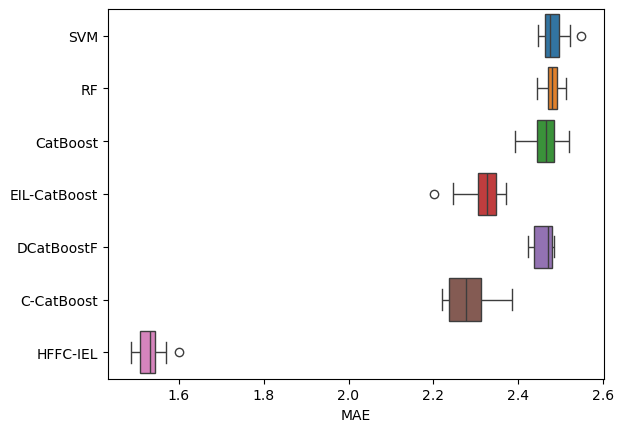

In [4]:
df = pd.DataFrame(columns=['SVM',"RF","CatBoost","EIL-CatBoost","DCatBoostF",'C-CatBoost','HFFC-IEL'])
i = 0
df["SVM"] = svms[:, i]
df["RF"] = rfs[:, i]
df["CatBoost"] = cats[:, i]
df["EIL-CatBoost"] = eils[:, i]
df["DCatBoostF"] = catsf[:, i]
df["C-CatBoost"] = ccats[:, i]
df["HFFC-IEL"] = hffcs[:, i]

ax = sns.boxplot(data=df,orient='h')#, x=x, y=y, hue=hue
ax.set(xlabel="MAE")

# plt.savefig('ensembleUCI.eps', format='eps')
plt.savefig('matMAEG1.eps', format='eps',bbox_inches  ='tight')

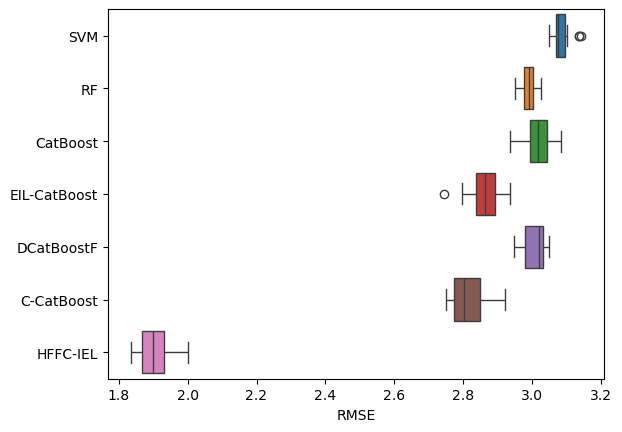

In [5]:
df = pd.DataFrame(columns=['SVM',"RF","CatBoost","EIL-CatBoost","DCatBoostF",'C-CatBoost','HFFC-IEL'])
i = 2
df["SVM"] = svms[:, i]
df["RF"] = rfs[:, i]
df["CatBoost"] = cats[:, i]
df["EIL-CatBoost"] = eils[:, i]
df["DCatBoostF"] = catsf[:, i]
df["C-CatBoost"] = ccats[:, i]
df["HFFC-IEL"] = hffcs[:, i]

ax = sns.boxplot(data=df,orient='h')#, x=x, y=y, hue=hue
ax.set(xlabel="RMSE")

# plt.savefig('ensembleUCI.eps', format='eps')
plt.savefig('matRMSEG1.eps', format='eps',bbox_inches  ='tight')

In [23]:
print(svms.std(axis=0))
print(rfs.std(axis=0))
print(cats.std(axis=0))
print(eils.std(axis=0))
print(catsf.std(axis=0))
print(ccats.std(axis=0))
print(hffcs.std(axis=0))

[0.02669948 0.02479482 0.02615479 0.00124063]
[0.01626925 0.02415219 0.02096327 0.00105929]
[0.0297707  0.03345716 0.0359541  0.00143541]
[0.04107434 0.04603454 0.04578555 0.00230423]
[0.02195858 0.02545188 0.03099176 0.00135375]
[0.04644957 0.04730564 0.04868323 0.0023637 ]
[0.02873491 0.04493197 0.04411331 0.00179063]


In [24]:
from scipy.stats import ranksums

def getTestResult(f1,f2,i):
    print(ranksums(np.asarray(f1[:,i]), np.asarray(f2[:,i])).pvalue)

i = 0
print(getTestResult(svms, hffcs,i))
print(getTestResult(rfs, hffcs,i))
print(getTestResult(cats, hffcs,i))
print(getTestResult(eils, hffcs,i))
print(getTestResult(catsf, hffcs,i))
print(getTestResult(ccats, hffcs,i))

i = 2
print(getTestResult(svms, hffcs,i))
print(getTestResult(rfs, hffcs,i))
print(getTestResult(cats, hffcs,i))
print(getTestResult(eils, hffcs,i))
print(getTestResult(catsf, hffcs,i))
print(getTestResult(ccats, hffcs,i))

6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
6.301848221392269e-08
None
